# The three $\alpha(p)$ curves: optimal, marginal, and pivotal

Rotated surface code Z-memory, circuit-level depolarizing, $d=5$. We put three different "$\alpha$" on
one axis versus the physical error rate $p$ and try to read off the **functional form** $\alpha(p)$ of each:

| curve | meaning | source |
|---|---|---|
| $\alpha_{\text{opt}}(p)$ | the $\alpha$ that **minimises the LER** of Pearl/damped CM | `alpha_sweep_extended_fixed_MWPM.csv` (argmin over the $\alpha$ grid) |
| $\alpha_{\text{all}}(p)$ | true $P(e_\nu\text{ fired}\mid e_\nu\text{ selected})$, **all** selected edges | `true_alpha_estimate.csv` |
| $\alpha_{\text{logical}}(p)$ | the same, but only on shots where CM **flips the logical decode** | `true_alpha_estimate.csv` |

**The puzzle.** If $\alpha$ were literally "the probability the selected edge fired," $\alpha_{\text{opt}}$
should equal one of the measured true $\alpha$'s. It does not: $\alpha_{\text{opt}}$ sweeps a full decade
($\approx0.1\to0.9$) while $\alpha_{\text{logical}}$ is nearly flat at $\frac{1}{2}$. So each curve has its own
law, and this notebook is about finding those laws.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)

# --- true alphas (marginal + pivotal), from the ground-truth estimator ---
ta = pd.read_csv(os.path.join(ROOT, "data", "true_alpha_estimate.csv")).sort_values("p").reset_index(drop=True)

# --- alpha sweep (for the optimal alpha) ---
sw = pd.read_csv(os.path.join(ROOT, "data", "alpha_sweep_extended_fixed_MWPM.csv"))
sw["alpha"] = pd.to_numeric(sw["alpha"], errors="coerce")
d5 = sw[(sw.distance == 5) & (sw.decoder == "cm")].copy()

# --- q = median pairwise posterior P(mu|nu), the O(1) constant in the reweight ---
from NeuralCM.syndrome_data_generation import SyndromeDataGenerator
from NeuralCM.decoding_graph import DecodingGraph
def posterior_q(p):
    gen = SyndromeDataGenerator(distance=5, n_rounds=5, mismatch=1.0,
        noise_model={"version": "built-in", "after_clifford_depolarization": p,
                     "before_measure_flip_probability": p, "after_reset_flip_probability": p,
                     "before_round_data_depolarization": p, "p_gate_zz": 0.0},
        memory_type="z", n_shots=1, qec_code="surface_code")
    _, dem, _ = gen.generate_base_circuit(); g = DecodingGraph.from_dem(dem)
    corr = np.asarray(g.initial_corr_tracer); base = np.asarray(g.base_p); line = np.asarray(g.line_edge_index)
    a, b = line[0], line[1]
    return float(np.median(np.concatenate([corr / base[b], corr / base[a]])))
q = posterior_q(1e-3)   # ~p-independent (checked in conditional_scaling_check.ipynb)
print(f"median pairwise posterior  q = P(mu|nu) = {q:.4f}   (used as the O(1) constant)")

median pairwise posterior  q = P(mu|nu) = 0.0654   (used as the O(1) constant)


## 1. Extract the optimal $\alpha$ per $p$

The sweep only samples $\alpha\in\{0.1,0.2,0.3,0.4,0.5,0.9,1.0\}$, so the grid argmin is coarse. Where the
minimum is interior we refine it with a **parabola through the argmin and its two neighbours** (vertex =
refined $\alpha_{\text{opt}}$); where it sits on the low boundary ($\alpha=0.1$) we can only report an upper
bound, flagged separately.

In [2]:
def optimal_alpha(g):
    g = g.sort_values("alpha")
    a = g.alpha.to_numpy(); ler = g.ler.to_numpy()
    i = int(np.argmin(ler))
    if 0 < i < len(a) - 1:                      # interior: parabolic refine
        xs, ys = a[i-1:i+2], ler[i-1:i+2]
        A, B, _ = np.polyfit(xs, ys, 2)
        av = -B / (2 * A) if A > 0 else a[i]
        return float(np.clip(av, xs[0], xs[-1])), (i == 0)
    return float(a[i]), (i == 0)                 # boundary: grid value (bound if i==0)

ps = np.array(sorted(d5.p.unique()))
aopt, is_bound = [], []
for p in ps:
    av, b = optimal_alpha(d5[d5.p == p]); aopt.append(av); is_bound.append(b)
aopt = np.array(aopt); is_bound = np.array(is_bound)

# align the true alphas onto the same p where available
def col(p, name):
    r = ta[np.isclose(ta.p, p)]
    return float(r[name].iloc[0]) if len(r) else np.nan
a_all = np.array([col(p, "alpha_all") for p in ps])
a_edge = np.array([col(p, "alpha_edge_changed") for p in ps])
a_log = np.array([col(p, "alpha_logical_changed") for p in ps])
a_log_lo = np.array([col(p, "alpha_lc_lo") for p in ps])
a_log_hi = np.array([col(p, "alpha_lc_hi") for p in ps])

print(f"{'p':>8} {'a_opt':>7} {'(bound?)':>8} {'a_all':>7} {'a_edge':>7} {'a_log':>7}")
for j, p in enumerate(ps):
    print(f"{p:>8.0e} {aopt[j]:>7.3f} {str(is_bound[j]):>8} "
          f"{a_all[j]:>7.3f} {a_edge[j]:>7.3f} {a_log[j]:>7.3f}")

       p   a_opt (bound?)   a_all  a_edge   a_log
   1e-04   0.119    False     nan     nan     nan
   2e-04   0.183    False   0.996   0.751   0.488
   4e-04   0.250    False   0.991   0.696   0.479
   7e-04   0.450    False   0.984   0.658   0.509
   1e-03   0.442    False   0.977   0.663   0.509
   2e-03   0.603    False   0.953   0.666   0.547
   4e-03   0.757    False     nan     nan     nan
   7e-03   0.744    False     nan     nan     nan
   1e-02   0.703    False   0.754   0.661   0.584


## 2. Master plot — all three $\alpha$ on one axis

$\alpha_{\text{all}}\to1$ as $p\to0$; $\alpha_{\text{logical}}$ hugs $\frac{1}{2}$; $\alpha_{\text{opt}}$ dives
from $\sim0.9$ toward $\sim0.1$. The three cross near $p\approx10^{-3}$ — that coincidence is *why* the naive
"optimal $\alpha$ = true trust" reading looks right in the mid-$p$ region and fails elsewhere.

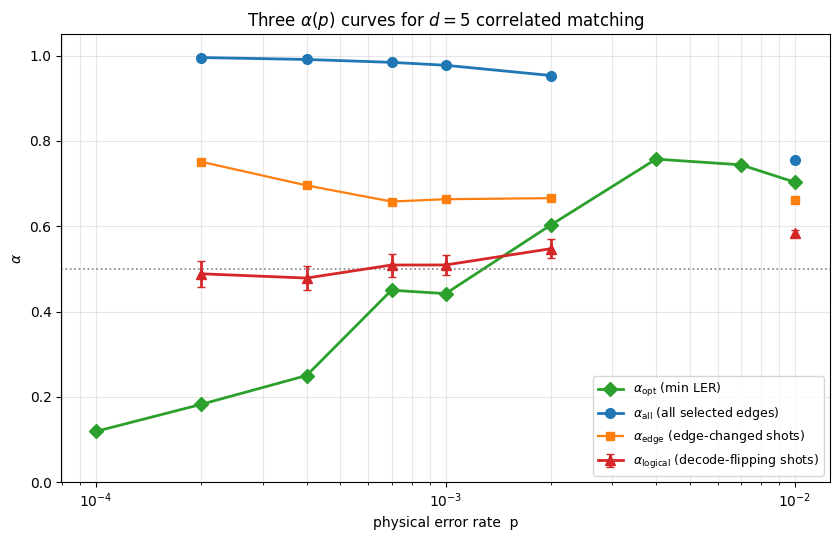

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.semilogx(ps, aopt, "-D", color="#2ca02c", ms=7, lw=2, label=r"$\alpha_{\rm opt}$ (min LER)")
if is_bound.any():
    ax.semilogx(ps[is_bound], aopt[is_bound], "v", color="#2ca02c", ms=11, mfc="none",
                label=r"$\alpha_{\rm opt}$ is an upper bound (grid edge)")
ax.semilogx(ps, a_all, "-o", color="#1f77b4", ms=7, lw=2, label=r"$\alpha_{\rm all}$ (all selected edges)")
ax.semilogx(ps, a_edge, "-s", color="#ff7f0e", ms=6, lw=1.6, label=r"$\alpha_{\rm edge}$ (edge-changed shots)")
ax.errorbar(ps, a_log, yerr=[a_log - a_log_lo, a_log_hi - a_log], fmt="-^", color="#d62728",
            ms=7, lw=2, capsize=3, label=r"$\alpha_{\rm logical}$ (decode-flipping shots)")
ax.axhline(0.5, color="gray", ls=":", lw=1.2)
ax.set_xlabel("physical error rate  p"); ax.set_ylabel(r"$\alpha$")
ax.set_title(r"Three $\alpha(p)$ curves for $d=5$ correlated matching")
ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "alpha_relations_master.png"), dpi=200, bbox_inches="tight")
plt.show()

## 3. $\alpha_{\text{all}}(p)\approx 1-A\,p$

$\alpha_{\text{all}}=P(\text{selected edge fired})$. A selection is wrong only when a *coincidence*
(a second fault or a degenerate cheaper path) makes MWPM pick an edge that did not fire; that phantom rate is
$O(p)$ at leading order. So the **defect** $1-\alpha_{\text{all}}$ should be linear in $p$:
$$1-\alpha_{\text{all}}(p)\approx A\,p,\qquad\text{i.e. log-log slope }\approx 1.$$

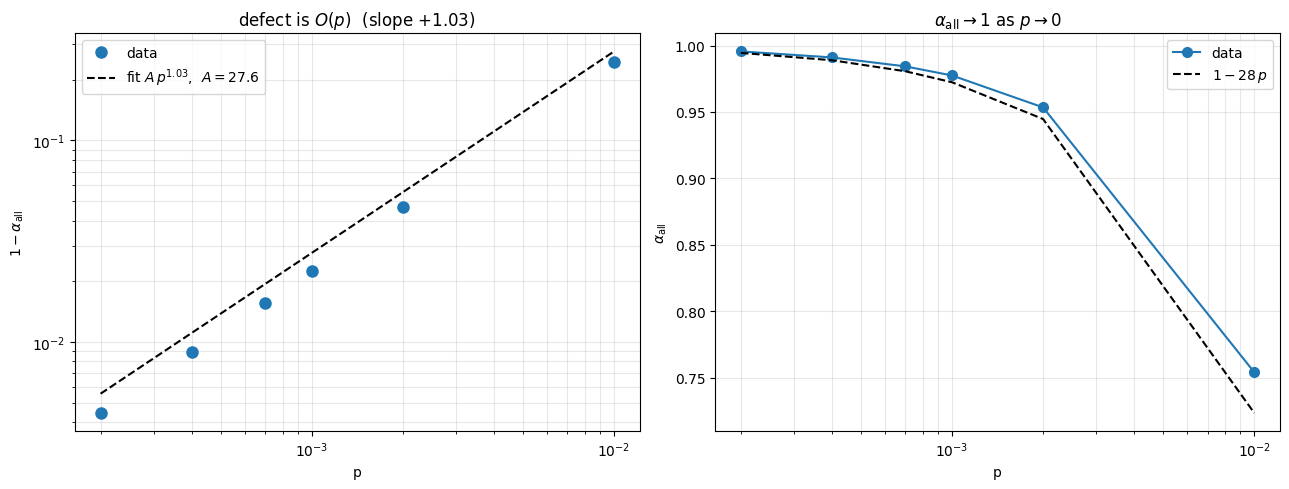

1 - alpha_all  ~  27.6 * p^1.03   (slope ~1 confirms the O(p) phantom-selection rate)


In [4]:
m = np.isfinite(a_all)                          # p=1e-4 has no true-alpha value
pf, af = ps[m], a_all[m]
defect = 1 - af
sl, inter = np.polyfit(np.log(pf), np.log(defect), 1)
A = np.exp(inter)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(pf, defect, "o", color="#1f77b4", ms=8, label="data")
ax[0].loglog(pf, A * pf, "k--", lw=1.5, label=fr"fit $A\,p^{{{sl:.2f}}}$,  $A={A:.1f}$")
ax[0].set_xlabel("p"); ax[0].set_ylabel(r"$1-\alpha_{\rm all}$")
ax[0].set_title(fr"defect is $O(p)$  (slope {sl:+.2f})"); ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

ax[1].semilogx(pf, af, "o-", color="#1f77b4", ms=7, label="data")
ax[1].semilogx(pf, 1 - A * pf, "k--", lw=1.5, label=fr"$1-{A:.0f}\,p$")
ax[1].set_xlabel("p"); ax[1].set_ylabel(r"$\alpha_{\rm all}$")
ax[1].set_title(r"$\alpha_{\rm all}\to 1$ as $p\to0$"); ax[1].legend(); ax[1].grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "alpha_all_fit.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"1 - alpha_all  ~  {A:.1f} * p^{sl:.2f}   (slope ~1 confirms the O(p) phantom-selection rate)")

## 4. $\alpha_{\text{logical}}(p)\approx \frac{1}{2}$

A shot is *logical-pivotal* only when the two competing matchings are a **near tie** — that is exactly the
condition under which the first-pass selection is a coin flip. So on those shots the selected edge fired with
probability $\approx\frac{1}{2}$, essentially independent of $p$ (a small $O(p)$ drift upward as ties become less
symmetric near threshold). The horizontal line $\frac{1}{2}$ is the model; the bootstrap CIs straddle it.

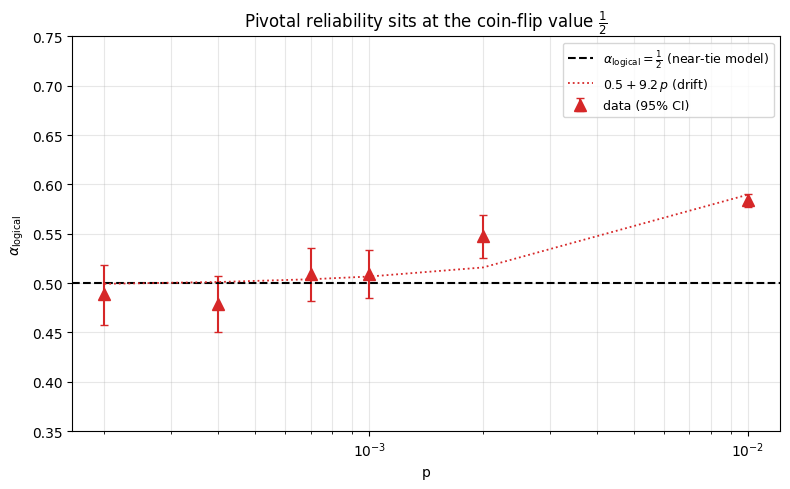

alpha_logical ~ 0.5 + 9.22 p   (intercept 0.497); flat within CI at low p


In [5]:
m = np.isfinite(a_log)
pf, af, lo, hi = ps[m], a_log[m], a_log_lo[m], a_log_hi[m]
sl2, in2 = np.polyfit(pf, af, 1)               # tiny linear drift
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(pf, af, yerr=[af - lo, hi - af], fmt="^", color="#d62728",
            ms=8, lw=1.5, capsize=3, label="data (95% CI)")
ax.axhline(0.5, color="k", ls="--", lw=1.5, label=r"$\alpha_{\rm logical}=\frac{1}{2}$ (near-tie model)")
ax.semilogx(pf, in2 + sl2 * pf, ":", color="#d62728", lw=1.3, label=fr"$0.5 + {sl2:.1f}\,p$ (drift)")
ax.set_xscale("log"); ax.set_xlabel("p"); ax.set_ylabel(r"$\alpha_{\rm logical}$")
ax.set_ylim(0.35, 0.75); ax.set_title(r"Pivotal reliability sits at the coin-flip value $\frac{1}{2}$")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "alpha_logical_fit.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"alpha_logical ~ 0.5 + {sl2:.2f} p   (intercept {in2:.3f}); flat within CI at low p")

## 5. $\alpha_{\text{opt}}(p)\propto\sqrt{p}$ — the "half-weight" law

This is the interesting one, and it is **not** a probability. The Pearl/damped reweight sets the neighbour
edge's implied probability to (damped-Bayes limit, since $P(\mu\mid\overline\nu)=O(p)$ is negligible)
$$\text{implied}_p \;\approx\; \alpha\,q,\qquad q=P(\mu\mid\nu)=O(1)\approx 0.065 .$$
Its **weight** is $w_{\rm new}=\log\frac{1-\text{implied}_p}{\text{implied}_p}$, to be compared with the edge's
baseline weight $w_0=\log\frac{1-p}{p}$, which **blows up as $p\to0$**. Reading off the observed optima, the
reweighted weight is always about **half** the baseline:
$$w_{\rm new}(\alpha_{\rm opt})\;\approx\;\frac{1}{2}\,w_0 .$$
Setting $w_{\rm new}=\frac{1}{2} w_0$ gives $\frac{1-\text{implied}}{\text{implied}}=\sqrt{\frac{1-p}{p}}$, so
$\text{implied}\approx\sqrt{p}$ at low $p$, and therefore
$$\boxed{\;\alpha_{\rm opt}(p)\;\approx\;\frac{\sqrt{p}}{q}\;}\quad(\text{capped at }1),\qquad
\text{i.e. }\alpha_{\rm opt}\propto\sqrt{p} .$$

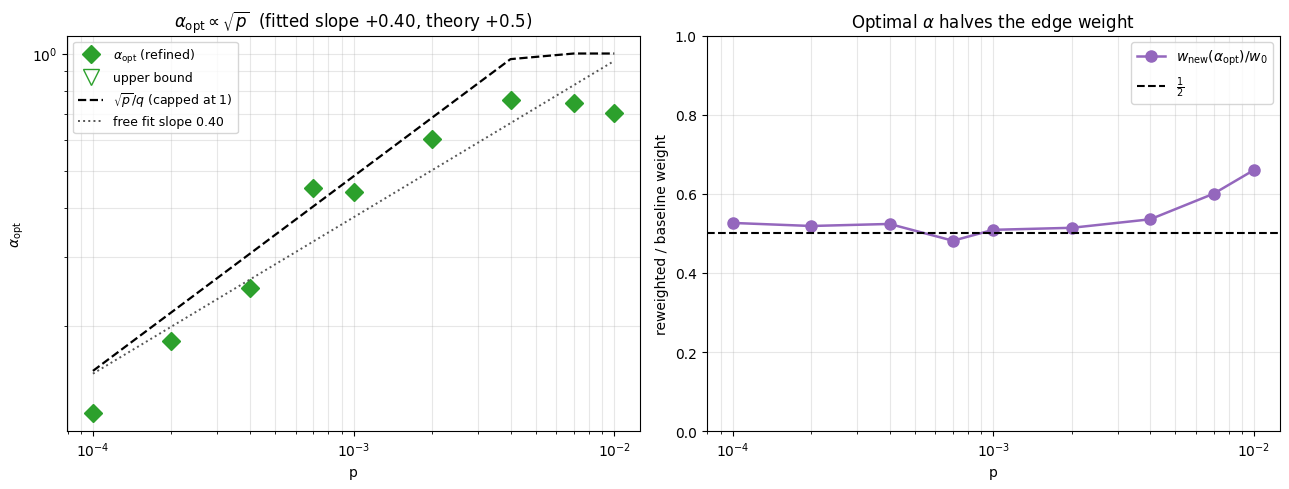

alpha_opt free-fit exponent = +0.40  (theory +0.5)
w_new/w0 across p: [0.526 0.519 0.524 0.481 0.509 0.514 0.535 0.6   0.66 ]   (mean 0.541)


In [6]:
# (a) the half-weight law: w_new(alpha_opt) / w0 ~ 0.5
implied = aopt * q
w_new = np.log((1 - implied) / implied)
w0 = np.log((1 - ps) / ps)
ratio = w_new / w0

# (b) sqrt(p) model for alpha_opt (fit slope on the non-capped points)
uncapped = aopt < 0.85
sl3, in3 = np.polyfit(np.log(ps[uncapped]), np.log(aopt[uncapped]), 1)
model = np.clip(np.sqrt(ps) / q, 0, 1.0)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(ps, aopt, "D", color="#2ca02c", ms=9, label=r"$\alpha_{\rm opt}$ (refined)")
ax[0].loglog(ps[is_bound], aopt[is_bound], "v", color="#2ca02c", ms=12, mfc="none", label="upper bound")
ax[0].loglog(ps, model, "k--", lw=1.6, label=r"$\sqrt{p}/q$ (capped at 1)")
ax[0].loglog(ps, np.exp(in3) * ps ** sl3, ":", color="#555", lw=1.4, label=fr"free fit slope {sl3:.2f}")
ax[0].set_xlabel("p"); ax[0].set_ylabel(r"$\alpha_{\rm opt}$")
ax[0].set_title(fr"$\alpha_{{\rm opt}}\propto\sqrt{{p}}$  (fitted slope {sl3:+.2f}, theory $+0.5$)")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3, which="both")

ax[1].semilogx(ps, ratio, "o-", color="#9467bd", ms=8, lw=1.8, label=r"$w_{\rm new}(\alpha_{\rm opt})/w_0$")
ax[1].axhline(0.5, color="k", ls="--", lw=1.5, label=r"$\frac{1}{2}$")
ax[1].set_ylim(0, 1); ax[1].set_xlabel("p"); ax[1].set_ylabel("reweighted / baseline weight")
ax[1].set_title(r"Optimal $\alpha$ halves the edge weight"); ax[1].legend(); ax[1].grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "alpha_opt_sqrt_law.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"alpha_opt free-fit exponent = {sl3:+.2f}  (theory +0.5)")
print(f"w_new/w0 across p: {ratio.round(3)}   (mean {ratio.mean():.3f})")

## 6. Synthesis — three different laws, one plot

| curve | law | origin |
|---|---|---|
| $\alpha_{\text{all}}(p)$ | $1-A\,p$ (slope-1 defect) | phantom selections are $O(p)$ coincidences; MWPM is almost always right at low $p$ |
| $\alpha_{\text{logical}}(p)$ | $\approx\frac{1}{2}$ | decode-flipping shots are near-ties, where the selection is a coin flip |
| $\alpha_{\text{opt}}(p)$ | $\sqrt{p}/q$ (slope-$\frac{1}{2}$) | **not a probability** — it is the shrinkage that keeps the reweighted weight at $\frac{1}{2} w_0$; the baseline weight $w_0=\log\frac{1-p}{p}$ diverges as $p\to0$, so the same posterior is a far more violent cut at low $p$ and must be damped $\propto\sqrt{p}$ |

**Reconciliation of the mismatch.** $\alpha_{\text{opt}}$ crosses $\alpha_{\text{logical}}\approx\frac{1}{2}$ near
$p\approx10^{-3}$, which is why the "optimal $\alpha$ = trust in the selection" reading looks right there. But
the two obey different laws: the pivotal reliability is flat at $\frac{1}{2}$ (it sets the *ceiling* — you never
want $\alpha=1$), whereas the optimal damping falls as $\sqrt{p}$ because it is governed by the **weight
magnitude**, not by any probability. So first-pass unreliability explains *why* CM must be damped; the
$\sqrt{p}$ growth of the required damping is a separate, weight-convention effect.

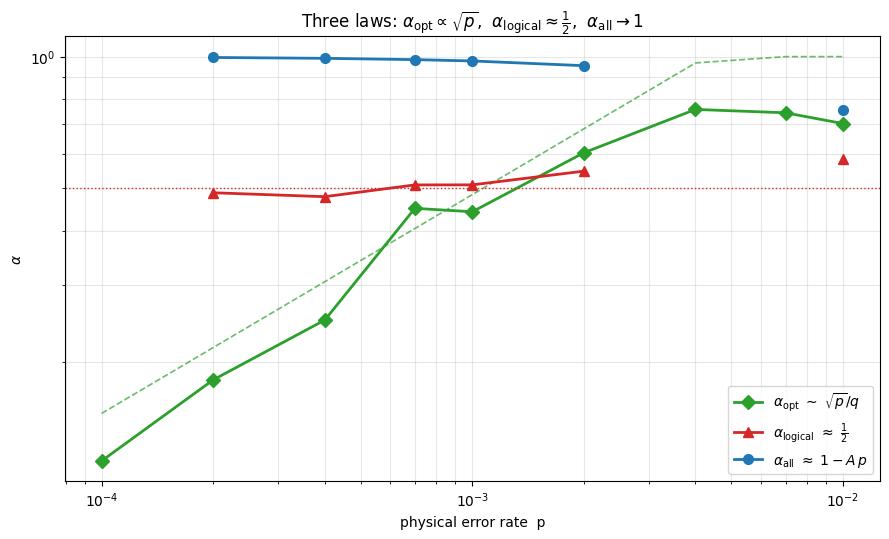

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(ps, aopt, "-D", color="#2ca02c", ms=7, lw=2, label=r"$\alpha_{\rm opt}\ \sim\ \sqrt{p}/q$")
ax.loglog(ps, np.clip(np.sqrt(ps) / q, 0, 1), "--", color="#2ca02c", lw=1.2, alpha=0.7)
ax.loglog(ps, a_log, "-^", color="#d62728", ms=7, lw=2, label=r"$\alpha_{\rm logical}\ \approx\ \frac{1}{2}$")
ax.axhline(0.5, color="#d62728", ls=":", lw=1)
ax.loglog(ps, a_all, "-o", color="#1f77b4", ms=7, lw=2, label=r"$\alpha_{\rm all}\ \approx\ 1-A\,p$")
ax.set_xlabel("physical error rate  p"); ax.set_ylabel(r"$\alpha$")
ax.set_title(r"Three laws: $\alpha_{\rm opt}\propto\sqrt{p}$,  $\alpha_{\rm logical}\approx\frac{1}{2}$,  $\alpha_{\rm all}\to1$")
ax.legend(fontsize=10); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "alpha_relations_laws.png"), dpi=200, bbox_inches="tight")
plt.show()